# Bank Term Deposit Subscription Prediction

## Business-Focused Machine Learning Project

**Goal:** Predict which customers are more likely to subscribe to a term deposit, so the bank can improve campaign targeting, reduce unnecessary calls, and increase conversion efficiency.

**Problem Type:** Binary Classification

**Target Variable:** `deposit`

In [4]:
%pip install -q pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## Project Context

This project focuses on a real business problem in direct marketing.  
A bank runs phone-based marketing campaigns to convince customers to subscribe to a term deposit. Since calling every customer is expensive and inefficient, the goal is to use machine learning to estimate which customers are more likely to subscribe before the call is made.

This turns the model into a practical decision-support tool rather than just a prediction exercise.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.datasets import get_data
from pycaret.classification import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

sns.set_theme(style="whitegrid")

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

## Step 1 — Load and Inspect the Dataset

We start by loading the dataset and checking its size, columns, and first few rows.  
This helps us verify the target variable and understand the structure of the dataset before any modeling.

In [6]:
df = get_data('bank').copy()

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [7]:
print(df.head(200))

     age            job   marital  education default  balance housing loan  \
0     58     management   married   tertiary      no     2143     yes   no   
1     44     technician    single  secondary      no       29     yes   no   
2     33   entrepreneur   married  secondary      no        2     yes  yes   
3     47    blue-collar   married    unknown      no     1506     yes   no   
4     33        unknown    single    unknown      no        1      no   no   
5     35     management   married   tertiary      no      231     yes   no   
6     28     management    single   tertiary      no      447     yes  yes   
7     42   entrepreneur  divorced   tertiary     yes        2     yes   no   
8     58        retired   married    primary      no      121     yes   no   
9     43     technician    single  secondary      no      593     yes   no   
10    41         admin.  divorced  secondary      no      270     yes   no   
11    29         admin.    single  secondary      no      390   

## Step 2 — Quick Data Audit

In this step, we inspect:
- data types
- missing values
- target distribution

This is especially important because an imbalanced target can make accuracy misleading.

In [8]:
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df['deposit'].value_counts())

print("\nTarget ratio:")
print(df['deposit'].value_counts(normalize=True).round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  deposit    45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing values per column:
age          0
job          0
marital      0
education    0
defaul

## Step 3 — Target Imbalance

The dataset is imbalanced, which means the positive class (`yes`) is much smaller than the negative class (`no`).

Because of this, accuracy alone is not enough.  
We will pay more attention to metrics such as:
- AUC
- Recall
- Precision
- F1-score

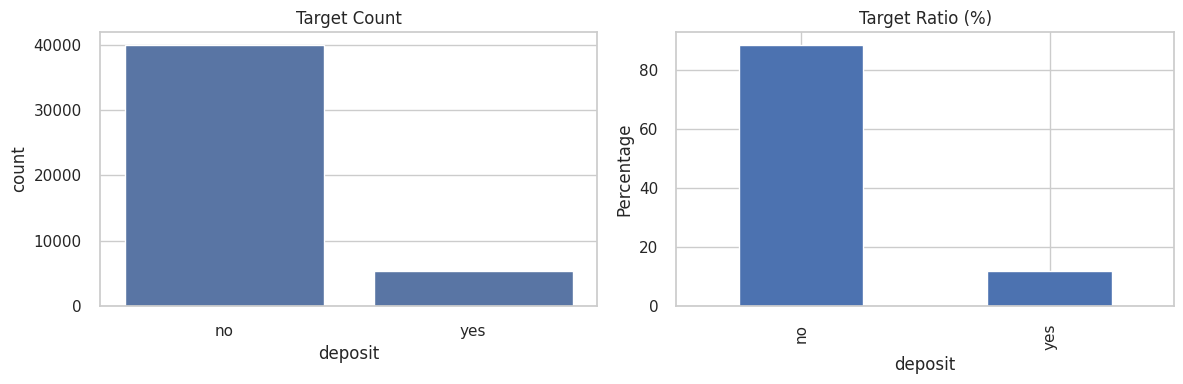

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='deposit', ax=axes[0])
axes[0].set_title('Target Count')

target_ratio = (df['deposit'].value_counts(normalize=True) * 100).round(2)
target_ratio.plot(kind='bar', ax=axes[1])
axes[1].set_title('Target Ratio (%)')
axes[1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

## Step 4 — Business Understanding of the Features

The dataset contains:
- customer demographic information
- financial indicators
- campaign interaction history

To make the analysis useful for business, we will inspect which customer groups show higher subscription rates.

In [10]:
def yes_rate_table(data, col):
    temp = data.copy()
    temp['deposit_yes'] = (temp['deposit'] == 'yes').astype(int)
    return (
        temp.groupby(col)['deposit_yes']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'yes_rate'})
        .sort_values('yes_rate', ascending=False)
        .round(3)
    )

In [11]:
for col in ['poutcome', 'contact', 'month', 'housing', 'loan', 'job', 'education']:
    print(f"\n===== {col.upper()} =====")
    display(yes_rate_table(df, col))


===== POUTCOME =====


,yes_rate,count
poutcome,,
success,0.647,1511
other,0.167,1840
failure,0.126,4901
unknown,0.092,36959



===== CONTACT =====


,yes_rate,count
contact,,
cellular,0.149,29285
telephone,0.134,2906
unknown,0.041,13020



===== MONTH =====


...

,yes_rate,count
loan,,
no,0.127,37967
yes,0.067,7244



===== JOB =====


,yes_rate,count
job,,
student,0.287,938
retired,0.228,2264
unemployed,0.155,1303
management,0.138,9458
admin.,0.122,5171
self-employed,0.118,1579
unknown,0.118,288
technician,0.111,7597
services,0.089,4154



===== EDUCATION =====


,yes_rate,count
education,,
tertiary,0.150,13301
unknown,0.136,1857
secondary,0.106,23202
primary,0.086,6851


## Step 5 — Numeric Feature Review

Next, we compare numeric variables across the two target classes to see whether subscribers and non-subscribers differ in age, balance, campaign activity, or previous interactions.

In [12]:
numeric_summary = (
    df.groupby('deposit')[['age', 'balance', 'campaign', 'previous', 'pdays', 'duration']]
    .agg(['mean', 'median'])
    .round(2)
)

display(numeric_summary)

age         balance        campaign        previous         pdays  \
          mean median     mean median     mean median     mean median   mean   
deposit                                                                        
no       40.84   39.0  1303.71  417.0     2.85    2.0     0.50    0.0  36.42   
yes      41.67   38.0  1804.27  733.0     2.14    2.0     1.17    0.0  68.70   

               duration         
        median     mean median  
deposit                         
no        -1.0   221.18  164.0  
yes       -1.0   537.29  426.0

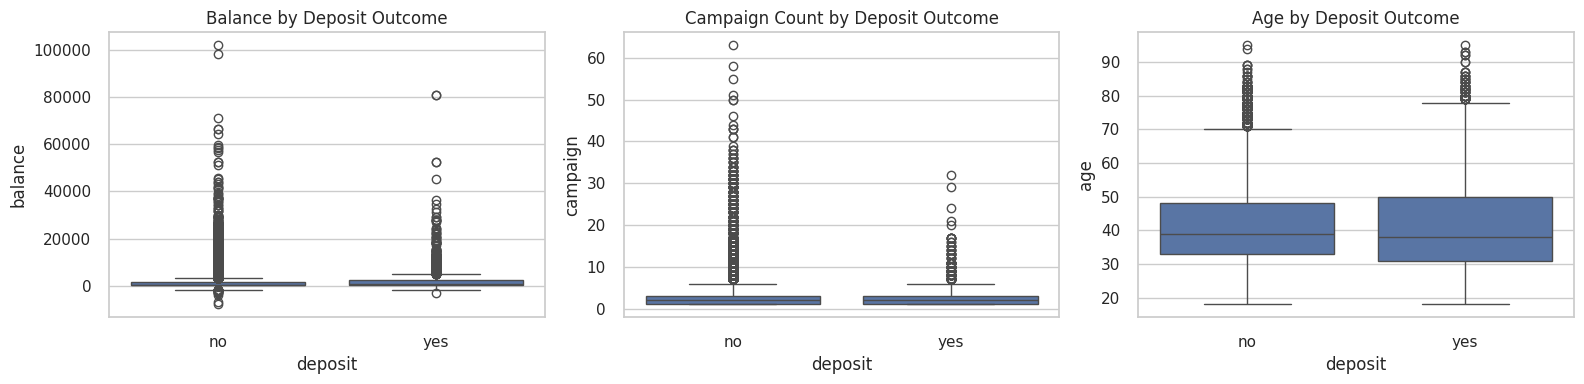

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x='deposit', y='balance', ax=axes[0])
axes[0].set_title('Balance by Deposit Outcome')

sns.boxplot(data=df, x='deposit', y='campaign', ax=axes[1])
axes[1].set_title('Campaign Count by Deposit Outcome')

sns.boxplot(data=df, x='deposit', y='age', ax=axes[2])
axes[2].set_title('Age by Deposit Outcome')

plt.tight_layout()
plt.show()

## Step 6 — Business Rule Before Modeling

The variable `duration` is intentionally excluded from the main model.

Why?  
Because call duration is only known after the call starts, while the business decision we want to support happens before the call is made.

Including it would improve model performance artificially, but it would make the model unrealistic for actual campaign planning.

## Step 7 — Feature Engineering

We now create new features that are easier to interpret from a business point of view.

Examples:
- age groups instead of raw age only
- balance segments
- whether the customer had previous contact
- whether previous campaign outcome was successful
- whether campaign pressure is high
- customer debt profile

In [15]:
df_model = df.copy()

# Age groups
df_model['age_group'] = pd.cut(
    df_model['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

# Balance segments
df_model['balance_segment'] = pd.cut(
    df_model['balance'],
    bins=[-np.inf, 0, 1000, 5000, np.inf],
    labels=['negative_or_zero', 'low', 'medium', 'high']
)

# High campaign pressure
df_model['campaign_pressure'] = np.where(df_model['campaign'] >= 3, 'high', 'normal')

# Debt profile
conditions = [
    (df_model['housing'] == 'yes') & (df_model['loan'] == 'yes'),
    (df_model['housing'] == 'yes') & (df_model['loan'] == 'no'),
    (df_model['housing'] == 'no') & (df_model['loan'] == 'yes')
]
choices = ['both_loans', 'housing_only', 'personal_only']

df_model['debt_profile'] = np.select(conditions, choices, default='no_debt')

print("Original shape:", df.shape)
print("Modeling shape:", df_model.shape)

display(df_model.head())

Original shape: (45211, 17)
Modeling shape: (45211, 21)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,balance_segment,campaign_pressure,debt_profile
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,51-60,medium,normal,housing_only
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,41-50,low,normal,housing_only
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,31-40,low,normal,both_loans
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,41-50,medium,normal,housing_only
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,31-40,low,normal,no_debt


In [16]:
for col in ['age_group', 'balance_segment', 'campaign_pressure', 'debt_profile']:
    print(f"\n===== {col.upper()} =====")
    display(yes_rate_table(df_model, col))


===== AGE_GROUP =====


,yes_rate,count
age_group,,
60+,0.423,1188
18-30,0.163,7030
31-40,0.102,17687
51-60,0.101,8067
41-50,0.091,11239



===== BALANCE_SEGMENT =====


,yes_rate,count
balance_segment,,
high,0.155,2845
medium,0.153,11786
low,0.109,23300
negative_or_zero,0.069,7280



===== CAMPAIGN_PRESSURE =====


,yes_rate,count
campaign_pressure,,
normal,0.132,30049
high,0.088,15162



===== DEBT_PROFILE =====


,yes_rate,count
debt_profile,,
no_debt,0.182,17204
housing_only,0.080,20763
personal_only,0.076,2877
both_loans,0.061,4367


## Step 8 — Modeling Strategy

We will build a business-realistic classification pipeline with the following decisions:

- target: `deposit`
- ignore `duration` to avoid leakage
- use stratified 5-fold cross-validation
- enable feature selection
- reduce multicollinearity
- address class imbalance
- compare at least two models

In [17]:
clf_exp = setup(
    data=df_model,
    target='deposit',
    session_id=42,
    train_size=0.8,
    fold=5,
    fold_strategy='stratifiedkfold',
    ignore_features=['duration'],
    feature_selection=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    fix_imbalance=True,
    categorical_imputation='mode',
    numeric_imputation='median',
    verbose=True
)

[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15046
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,42
1,Target,deposit
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(45211, 21)"
5,Transformed data shape,"(72917, 4)"
6,Transformed train set shape,"(63874, 4)"
7,Transformed test set shape,"(9043, 4)"
8,Ignore features,1
9,Numeric features,6


## Step 9 — Compare Candidate Models

We compare several candidate models using cross-validation.  
The goal is not just to get the highest score, but to choose a model that balances predictive performance and business usefulness.

In [18]:
candidate_models = ['lr', 'rf', 'gbc', 'ada']

top_models = compare_models(
    include=candidate_models,
    sort='AUC',
    n_select=4
)

compare_results = pull()
display(compare_results)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.6542,0.6409,0.6542,0.8272,0.7139,0.1036,0.1300,4.8640
gbc,Gradient Boosting Classifier,0.8398,0.6388,0.8398,0.8272,0.8330,0.1613,0.1624,9.6180
rf,Random Forest Classifier,0.8304,0.6322,0.8304,0.8252,0.8273,0.1518,0.1530,15.1640
lr,Logistic Regression,0.6452,0.5861,0.6452,0.8165,0.7046,0.0779,0.0929,5.8780


Processing:   0%|          | 0/24 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.6542,0.6409,0.6542,0.8272,0.7139,0.1036,0.1300,4.864
gbc,Gradient Boosting Classifier,0.8398,0.6388,0.8398,0.8272,0.8330,0.1613,0.1624,9.618
rf,Random Forest Classifier,0.8304,0.6322,0.8304,0.8252,0.8273,0.1518,0.1530,15.164
lr,Logistic Regression,0.6452,0.5861,0.6452,0.8165,0.7046,0.0779,0.0929,5.878


In [19]:
lr_model = create_model('lr')
lr_cv_results = pull().copy()

print("Logistic Regression - Cross Validation Results")
display(lr_cv_results)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7303,0.6305,0.7303,0.8273,0.7687,0.1324,0.1473
1,0.5729,0.5545,0.5729,0.8091,0.6491,0.0388,0.0543
2,0.7285,0.6144,0.7285,0.8269,0.7673,0.1310,0.1460
3,0.5933,0.5667,0.5933,0.8103,0.6658,0.0448,0.0605
4,0.6009,0.5645,0.6009,0.8089,0.6719,0.0424,0.0563
Mean,0.6452,0.5861,0.6452,0.8165,0.7046,0.0779,0.0929
Std,0.0694,0.0304,0.0694,0.0087,0.0523,0.0440,0.0440


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Logistic Regression - Cross Validation Results


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7303,0.6305,0.7303,0.8273,0.7687,0.1324,0.1473
1,0.5729,0.5545,0.5729,0.8091,0.6491,0.0388,0.0543
2,0.7285,0.6144,0.7285,0.8269,0.7673,0.1310,0.1460
3,0.5933,0.5667,0.5933,0.8103,0.6658,0.0448,0.0605
4,0.6009,0.5645,0.6009,0.8089,0.6719,0.0424,0.0563
Mean,0.6452,0.5861,0.6452,0.8165,0.7046,0.0779,0.0929
Std,0.0694,0.0304,0.0694,0.0087,0.0523,0.0440,0.0440


In [20]:
rf_model = create_model('rf')
rf_cv_results = pull().copy()

print("Random Forest - Cross Validation Results")
display(rf_cv_results)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8166,0.6321,0.8166,0.8295,0.8227,0.1733,0.1740
1,0.8384,0.6388,0.8384,0.8206,0.8289,0.1287,0.1301
2,0.8208,0.6341,0.8208,0.8328,0.8265,0.1899,0.1906
3,0.8417,0.6297,0.8417,0.8219,0.8309,0.1337,0.1357
4,0.8345,0.6261,0.8345,0.8213,0.8276,0.1335,0.1343
Mean,0.8304,0.6322,0.8304,0.8252,0.8273,0.1518,0.1530
Std,0.0099,0.0042,0.0099,0.0050,0.0027,0.0249,0.0246


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Random Forest - Cross Validation Results


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8166,0.6321,0.8166,0.8295,0.8227,0.1733,0.1740
1,0.8384,0.6388,0.8384,0.8206,0.8289,0.1287,0.1301
2,0.8208,0.6341,0.8208,0.8328,0.8265,0.1899,0.1906
3,0.8417,0.6297,0.8417,0.8219,0.8309,0.1337,0.1357
4,0.8345,0.6261,0.8345,0.8213,0.8276,0.1335,0.1343
Mean,0.8304,0.6322,0.8304,0.8252,0.8273,0.1518,0.1530
Std,0.0099,0.0042,0.0099,0.0050,0.0027,0.0249,0.0246


## Step 11 — Tune the Stronger Model

After identifying a stronger model, we improve it using hyperparameter tuning.  
This helps us push performance further while keeping the workflow systematic.

In [21]:
tuned_rf_model = tune_model(
    rf_model,
    optimize='AUC',
    choose_better=True
)

tuned_rf_results = pull().copy()

print("Tuned Random Forest - Cross Validation Results")
display(tuned_rf_results)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7550,0.6637,0.7550,0.8359,0.7872,0.1734,0.1888
1,0.6926,0.6262,0.6926,0.8254,0.7422,0.1118,0.1315
2,0.7459,0.6564,0.7459,0.8294,0.7795,0.1468,0.1601
3,0.7057,0.6334,0.7057,0.8292,0.7521,0.1286,0.1492
4,0.7109,0.6297,0.7109,0.8254,0.7550,0.1188,0.1357
Mean,0.7220,0.6419,0.7220,0.8291,0.7632,0.1359,0.1531
Std,0.0242,0.0152,0.0242,0.0038,0.0172,0.0222,0.0206


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Tuned Random Forest - Cross Validation Results


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7550,0.6637,0.7550,0.8359,0.7872,0.1734,0.1888
1,0.6926,0.6262,0.6926,0.8254,0.7422,0.1118,0.1315
2,0.7459,0.6564,0.7459,0.8294,0.7795,0.1468,0.1601
3,0.7057,0.6334,0.7057,0.8292,0.7521,0.1286,0.1492
4,0.7109,0.6297,0.7109,0.8254,0.7550,0.1188,0.1357
Mean,0.7220,0.6419,0.7220,0.8291,0.7632,0.1359,0.1531
Std,0.0242,0.0152,0.0242,0.0038,0.0172,0.0222,0.0206


## Step 12 — Holdout Evaluation

Cross-validation is useful for model comparison, but we also evaluate the models on the holdout set to estimate how they perform on unseen data.

In [22]:
lr_holdout_pred = predict_model(lr_model)
lr_holdout_metrics = pull().copy()

print("Logistic Regression - Holdout Results")
display(lr_holdout_metrics)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.5733,0.5670,0.5733,0.8091,0.6494,0.0390,0.0544


Logistic Regression - Holdout Results


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.5733,0.567,0.5733,0.8091,0.6494,0.039,0.0544


In [23]:
rf_holdout_pred = predict_model(tuned_rf_model)
rf_holdout_metrics = pull().copy()

print("Tuned Random Forest - Holdout Results")
display(rf_holdout_metrics)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.7147,0.6448,0.7147,0.8278,0.7581,0.1282,0.1462


Tuned Random Forest - Holdout Results


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.7147,0.6448,0.7147,0.8278,0.7581,0.1282,0.1462


## Step 13 — Model Diagnostics

We inspect:
- ROC AUC
- confusion matrix
- feature importance

This helps us understand both performance and business drivers.

In [24]:
evaluate_model(tuned_rf_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

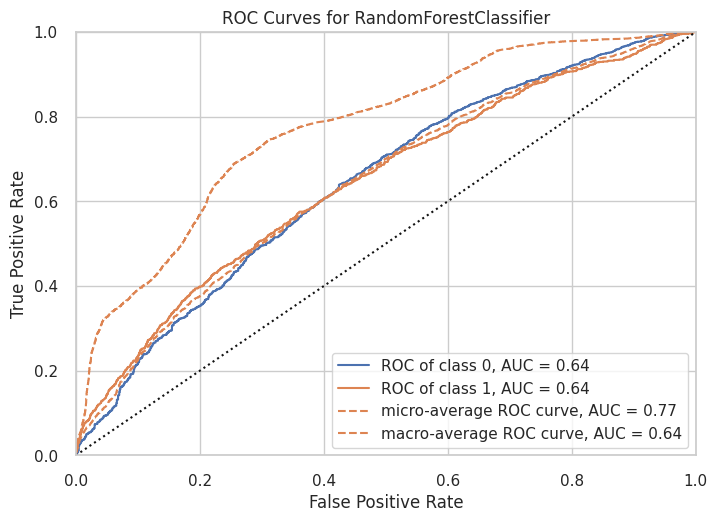

In [26]:
plot_model(tuned_rf_model, plot='auc')

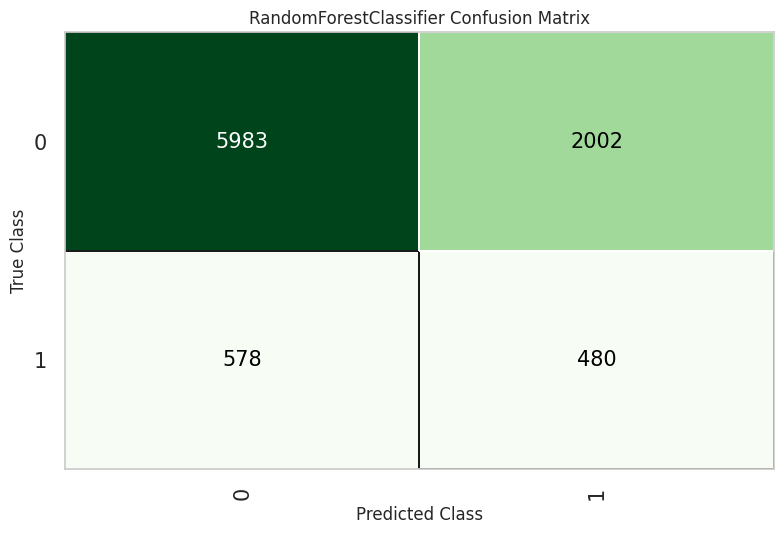

In [27]:
plot_model(tuned_rf_model, plot='confusion_matrix')

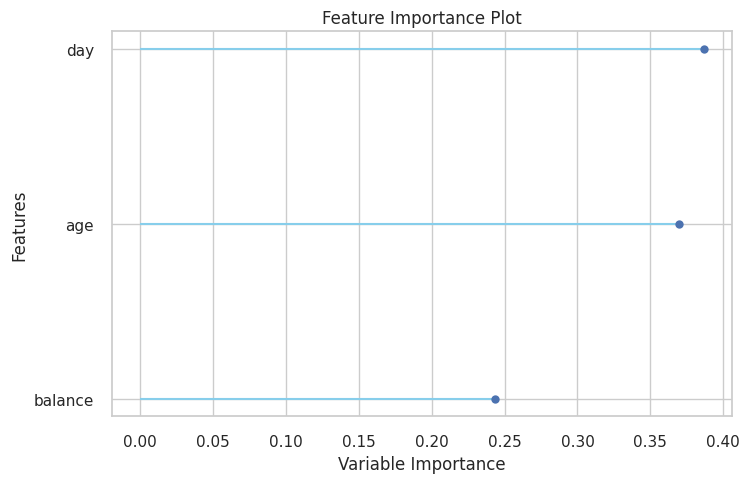

In [28]:
plot_model(tuned_rf_model, plot='feature')

## Step 14 — Business Use of Predictions

The model is not only used to classify customers as likely or unlikely subscribers.  
It can also be used to rank customers by probability, which allows the bank to prioritize its call list and allocate campaign resources more efficiently.

In [29]:
holdout_predictions = predict_model(tuned_rf_model)

print("Prediction columns:")
print(holdout_predictions.columns.tolist())

top_leads = (
    holdout_predictions[holdout_predictions['prediction_label'] == 'yes']
    .sort_values('prediction_score', ascending=False)
    [['age', 'job', 'marital', 'education', 'balance',
      'housing', 'loan', 'contact', 'month', 'campaign',
      'poutcome', 'prediction_label', 'prediction_score']]
    .head(20)
)

display(top_leads)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.7147,0.6448,0.7147,0.8278,0.7581,0.1282,0.1462


Prediction columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'age_group', 'balance_segment', 'campaign_pressure', 'debt_profile', 'deposit', 'prediction_label', 'prediction_score']


,age,job,marital,education,balance,housing,loan,contact,month,campaign,poutcome,prediction_label,prediction_score
43904,67,retired,married,unknown,2540,no,no,telephone,jun,5,other,yes,0.8806
41928,64,management,married,tertiary,4688,no,no,cellular,oct,1,unknown,yes,0.8780
33717,67,retired,single,tertiary,2144,no,no,telephone,apr,2,unknown,yes,0.8695
42176,64,entrepreneur,married,tertiary,2331,no,no,telephone,nov,1,unknown,yes,0.8675
33700,65,retired,married,tertiary,1973,no,no,telephone,apr,3,unknown,yes,0.8627
41919,67,retired,married,tertiary,3810,no,no,cellular,oct,1,unknown,yes,0.8590
41129,71,retired,married,unknown,1741,no,no,cellular,aug,1,unknown,yes,0.8584
44786,68,retired,divorced,primary,2027,no,no,cellular,sep,2,success,yes,0.8570
34337,63,management,married,unknown,2352,no,no,telephone,may,7,unknown,yes,0.8522
45180,66,retired,married,secondary,3409,no,no,cellular,nov,2,failure,yes,0.8509


## Additional Evaluation Visualizations

In this section, we add extra evaluation plots to better understand the model from both technical and business perspectives.

These visualizations help answer questions such as:
- How well does the model separate likely subscribers from non-subscribers?
- How useful is the score for customer ranking?
- How much business value does the model create when used for targeting?

In [30]:
plot_df = holdout_predictions.copy()

plot_df['actual_yes'] = (plot_df['deposit'] == 'yes').astype(int)
plot_df['pred_yes'] = (plot_df['prediction_label'] == 'yes').astype(int)
plot_df['score'] = plot_df['prediction_score']

print(plot_df[['deposit', 'prediction_label', 'prediction_score']].head())

      deposit prediction_label  prediction_score
1392       no               no            0.5422
7518       no               no            0.6482
12007      no               no            0.6414
5536       no               no            0.5062
29816      no              yes            0.5717


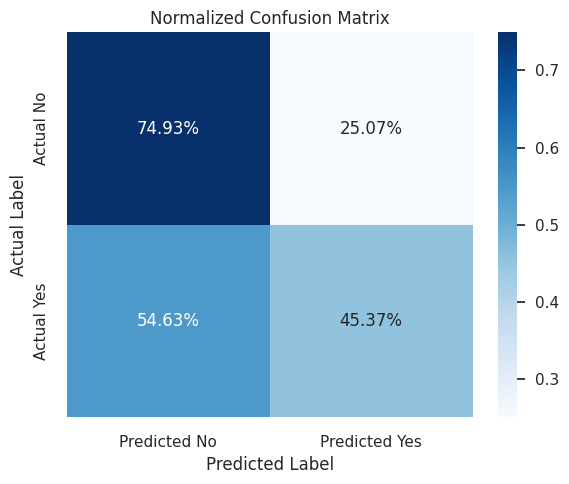

In [31]:
cm = confusion_matrix(plot_df['deposit'], plot_df['prediction_label'], labels=['no', 'yes'])
cm_percent = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

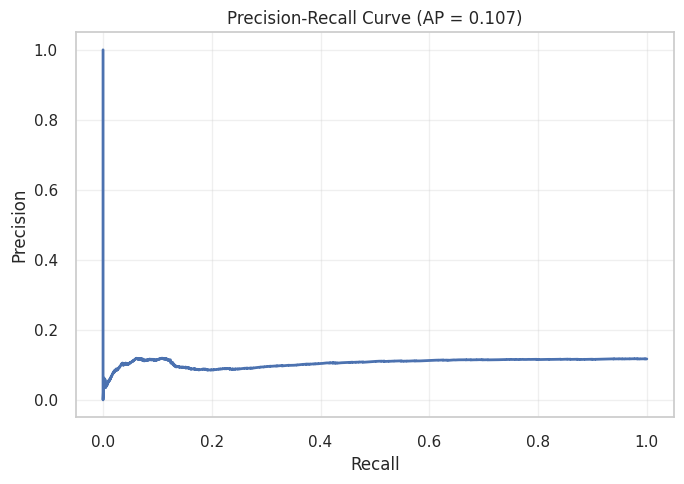

In [32]:
precision, recall, thresholds = precision_recall_curve(plot_df['actual_yes'], plot_df['score'])
ap = average_precision_score(plot_df['actual_yes'], plot_df['score'])

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2)
plt.title(f'Precision-Recall Curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

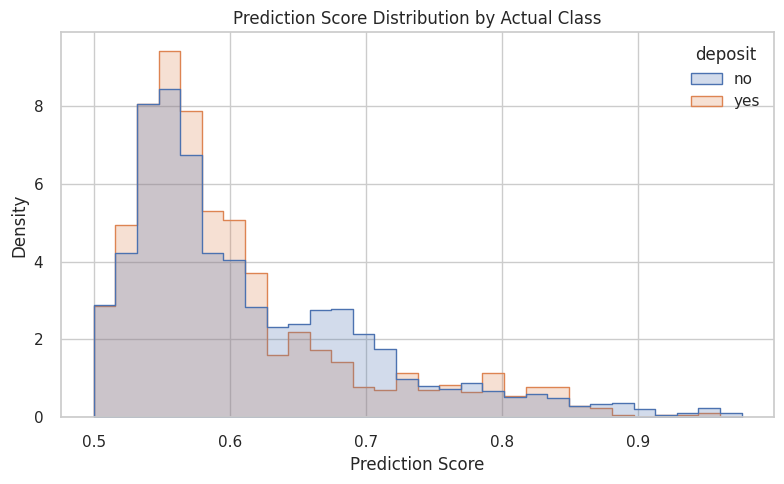

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=plot_df,
    x='score',
    hue='deposit',
    bins=30,
    stat='density',
    common_norm=False,
    element='step'
)

plt.title('Prediction Score Distribution by Actual Class')
plt.xlabel('Prediction Score')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

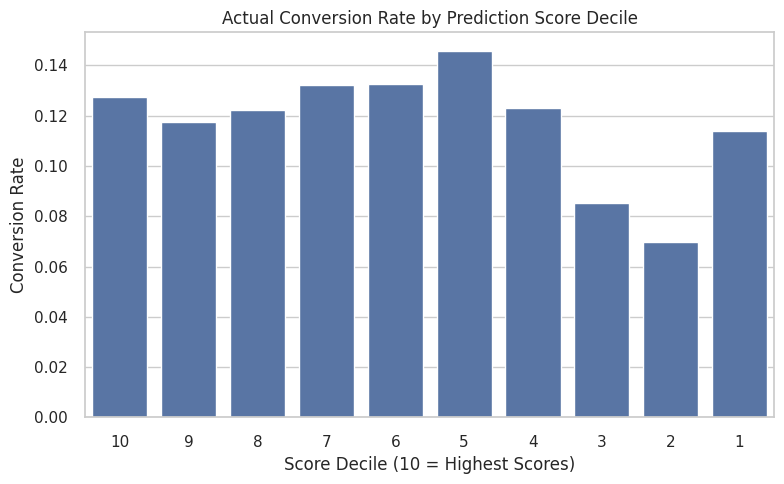

,score_decile,customers,actual_conversion_rate
0,10,909,0.127613
1,9,902,0.117517
2,8,908,0.122247
3,7,899,0.132369
4,6,904,0.132743
5,5,905,0.145856
6,4,903,0.122924
7,3,904,0.085177
8,2,904,0.069690
9,1,905,0.113812


In [34]:
decile_df = plot_df.copy()

decile_df['score_decile'] = pd.qcut(
    decile_df['score'],
    10,
    labels=[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
)

decile_summary = (
    decile_df.groupby('score_decile')
    .agg(
        customers=('actual_yes', 'count'),
        actual_conversion_rate=('actual_yes', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=decile_summary, x='score_decile', y='actual_conversion_rate')
plt.title('Actual Conversion Rate by Prediction Score Decile')
plt.xlabel('Score Decile (10 = Highest Scores)')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

display(decile_summary)

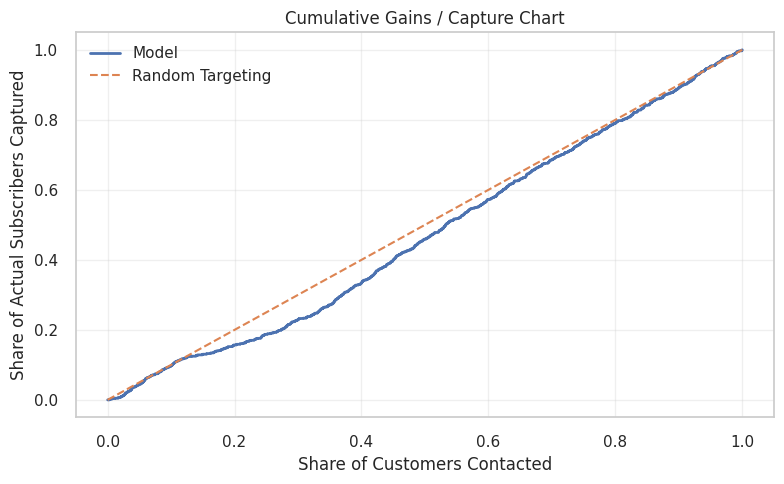

In [35]:
gains_df = plot_df[['actual_yes', 'score']].copy()
gains_df = gains_df.sort_values('score', ascending=False).reset_index(drop=True)

gains_df['cum_customers_pct'] = (np.arange(1, len(gains_df) + 1) / len(gains_df))
gains_df['cum_positives'] = gains_df['actual_yes'].cumsum()
gains_df['cum_capture_rate'] = gains_df['cum_positives'] / gains_df['actual_yes'].sum()

plt.figure(figsize=(8, 5))
plt.plot(gains_df['cum_customers_pct'], gains_df['cum_capture_rate'], linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Targeting')
plt.title('Cumulative Gains / Capture Chart')
plt.xlabel('Share of Customers Contacted')
plt.ylabel('Share of Actual Subscribers Captured')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

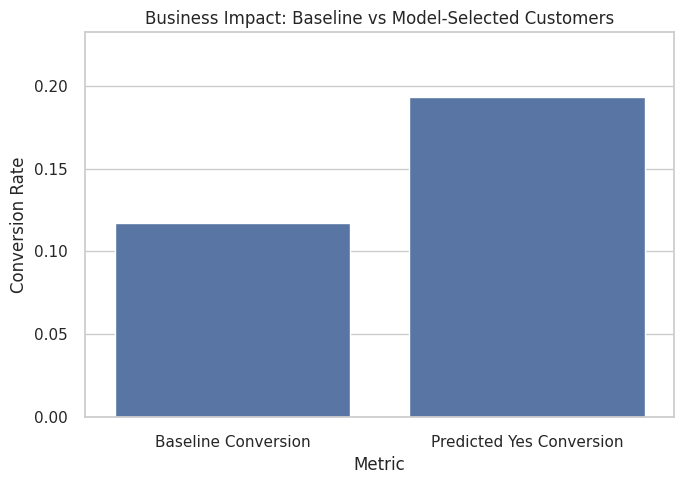

,Metric,Value
0,Baseline Conversion,0.116997
1,Predicted Yes Conversion,0.193392


In [36]:
baseline_conversion = (plot_df['actual_yes']).mean()
predicted_yes_conversion = plot_df.loc[plot_df['pred_yes'] == 1, 'actual_yes'].mean()

business_compare = pd.DataFrame({
    'Metric': ['Baseline Conversion', 'Predicted Yes Conversion'],
    'Value': [baseline_conversion, predicted_yes_conversion]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=business_compare, x='Metric', y='Value')
plt.title('Business Impact: Baseline vs Model-Selected Customers')
plt.ylabel('Conversion Rate')
plt.ylim(0, max(business_compare['Value']) * 1.2)
plt.tight_layout()
plt.show()

display(business_compare)

In [37]:
top_leads.to_csv('top_leads.csv', index=False)
print("Saved: top_leads.csv")

Saved: top_leads.csv


## Step 15 — Finalize and Save the Model

After choosing the final model, we train it on the full dataset and save it for future inference or deployment.

In [38]:
final_model = finalize_model(tuned_rf_model)
save_model(final_model, 'bank_deposit_model')

print("Final model saved successfully.")

Transformation Pipeline and Model Successfully Saved
Final model saved successfully.


In [39]:
sample_customers = df_model.drop(columns=['deposit']).sample(5, random_state=42)
sample_predictions = predict_model(final_model, data=sample_customers)

display(sample_predictions)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,age_group,balance_segment,campaign_pressure,debt_profile,prediction_label,prediction_score
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,...,1,-1,0,unknown,31-40,low,normal,housing_only,no,0.5556
9928,47,services,single,secondary,no,3644,no,no,unknown,9,...,2,-1,0,unknown,41-50,medium,normal,no_debt,yes,0.5586
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,...,1,-1,0,unknown,18-30,low,normal,housing_only,no,0.5870
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,...,1,336,1,failure,41-50,medium,normal,no_debt,yes,0.6001
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,...,2,-1,0,unknown,51-60,low,normal,personal_only,no,0.5944


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = holdout_predictions['deposit']
y_pred = holdout_predictions['prediction_label']

print(classification_report(y_true, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

          no     0.9119    0.7493    0.8226      7985
         yes     0.1934    0.4537    0.2712      1058

    accuracy                         0.7147      9043
   macro avg     0.5526    0.6015    0.5469      9043
weighted avg     0.8278    0.7147    0.7581      9043


Confusion Matrix:
[[5983 2002]
 [ 578  480]]


In [41]:
cm = confusion_matrix(y_true, y_pred, labels=['no', 'yes'])
tn, fp, fn, tp = cm.ravel()

baseline_conversion = (y_true == 'yes').mean()
predicted_yes_rate = tp / (tp + fp)
capture_rate = tp / (tp + fn)
contact_rate = (tp + fp) / len(y_true)
lift = predicted_yes_rate / baseline_conversion

print(f"Baseline conversion rate: {baseline_conversion:.4f}")
print(f"Conversion rate among predicted 'yes': {predicted_yes_rate:.4f}")
print(f"Lift: {lift:.2f}x")
print(f"Capture rate of actual subscribers: {capture_rate:.4f}")
print(f"Share of customers flagged for contact: {contact_rate:.4f}")

Baseline conversion rate: 0.1170
Conversion rate among predicted 'yes': 0.1934
Lift: 1.65x
Capture rate of actual subscribers: 0.4537
Share of customers flagged for contact: 0.2745


## Final Conclusion

The final model helps the bank identify customers who are more likely to subscribe to a term deposit before making the call.

### Key project decisions:
- We treated this as a binary classification problem
- We excluded `duration` to keep the model realistic for pre-call decision making
- We engineered business-interpretable features
- We used feature selection and stratified cross-validation
- We compared a baseline model against a stronger model
- We used predicted probabilities to prioritize customer outreach

### Business impact:
This approach can improve campaign efficiency, reduce wasted calls, and support smarter marketing decisions.

## Notes for Presentation

In the final presentation, focus on:
1. the business problem
2. why accuracy alone is misleading
3. why `duration` was excluded
4. which engineered features were added
5. why the final model was selected
6. how the bank can use prediction scores to prioritize leads